<a href="https://colab.research.google.com/github/Brunolms11/Calc_Numerico/blob/main/Atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3 - Parte A

In [29]:
#Importando as bibliotecas e definindo os valores

import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
valores_x = {"x1": 3.14159265, "x2":98.76543, "x3" : 0.00498765}
resultados = []

In [30]:
#Definindo a funcao de truncamento usando a definicao do enunciado
def trunc (x,n):
  return (math.trunc((10**n)*x))/(10**n)


In [31]:
for nome,valor in valores_x.items():
  for i in range(5):

    x_trunc = trunc(valor,i)
    x_rounded = round(valor,i)
    #Calculos dos erros para Truncamento
    Ea_trunc = abs(valor - x_trunc)
    Er_trunc = Ea_trunc / abs(valor)
    Ep_trunc = Er_trunc * 100

    #Calculos dos erros para Arredondamento
    Ea_round = abs(valor - x_rounded)
    Er_round = Ea_round / abs(valor)
    Ep_round = Er_round * 100

    resultados.append( {
                "Variável": nome,
                "n": i,
                "x": valor,
                "Truncado": x_trunc,
                "Ea (Trunc)": Ea_trunc,
                "Er (Trunc)": Er_trunc,
                "E% (Trunc)": Ep_trunc,
                "Arredondado": x_rounded,
                "Ea (Arred)": Ea_round,
                "Er (Arred)": Er_round,
                "E% (Arred)": Ep_round,
            }
        )
#Exibicao e Organizacao dos resultados
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

Variável  n         x  Truncado  Ea (Trunc)   Er (Trunc)  E% (Trunc)  Arredondado  Ea (Arred)   Er (Arred)  E% (Arred)
      x1  0  3.141593    3.0000    0.141593 4.507034e-02    4.507034       3.0000    0.141593 4.507034e-02    4.507034
      x1  1  3.141593    3.1000    0.041593 1.323935e-02    1.323935       3.1000    0.041593 1.323935e-02    1.323935
      x1  2  3.141593    3.1400    0.001593 5.069562e-04    0.050696       3.1400    0.001593 5.069562e-04    0.050696
      x1  3  3.141593    3.1410    0.000593 1.886464e-04    0.018865       3.1420    0.000407 1.296635e-04    0.012966
      x1  4  3.141593    3.1415    0.000093 2.949141e-05    0.002949       3.1416    0.000007 2.339578e-06    0.000234
      x2  0 98.765430   98.0000    0.765430 7.749979e-03    0.774998      99.0000    0.234570 2.375021e-03    0.237502
      x2  1 98.765430   98.7000    0.065430 6.624788e-04    0.066248      98.8000    0.034570 3.500213e-04    0.035002
      x2  2 98.765430   98.7600    0.005430 5.49

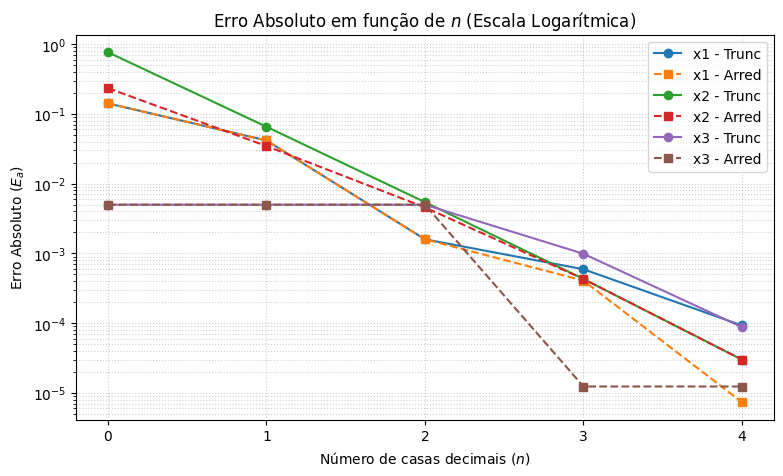

In [32]:
# Criar a figura
plt.figure(figsize=(9, 5))
n_valores = [0,1,2,3,4]
for nome, x in valores_x.items():
    Ea_trunc = [abs(x - trunc(x, n)) for n in range(5)]
    Ea_arred = [abs(x - round(x, n)) for n in range(5)]

    # Plota a linha de truncamento (contínua) e de arredondamento (tracejada)
    plt.plot(n_valores, Ea_trunc, marker="o", label=f"{nome} - Trunc")
    plt.plot(
        n_valores, Ea_arred, marker="s", linestyle="--", label=f"{nome} - Arred"
    )

# Escala logarítmica no eixo Y
plt.yscale("log")

# Formatação do gráfico
plt.xlabel("Número de casas decimais ($n$)")
plt.ylabel("Erro Absoluto ($E_a$)")
plt.title("Erro Absoluto em função de $n$ (Escala Logarítmica)")
plt.xticks(n_valores)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()

Parte A.
5 - Arredondar sempre gera um erro menor ou igual do que ao fazer por truncamento, como evidenciado nos resultados, pois nao houve nenhum tipo de erro em nenhum valor truncado que obteve um resultado menor do que ao usar dados arredondados

# 4 - PARTE B

B.1

In [33]:

#Definindo as Series para calcular os valores estatisticos em seguida

dados_originais = [121.7,120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
print(dados_originais)
#Criando listas para armazenar os valores
dados_arredondandos =[]
dados_trunc =[]
#calculando dados arredondados
for d in dados_originais:
  dados_arredondandos.append(round(d))
print(dados_arredondandos)
#calculando dados truncados para inteiros
for d in dados_originais:
  dados_trunc.append(trunc(d,0))
print(dados_trunc)


[121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
[122, 120, 122, 120, 121, 121, 122, 121, 120, 122]
[121.0, 120.0, 122.0, 119.0, 121.0, 120.0, 122.0, 121.0, 120.0, 121.0]


In [34]:
#---Estatisticas dados originais---
estat_dados_originais ={}
media_o = np.mean(dados_originais)
#como a media de referencia deve ser a calculada usando todos os algarismos disponiveis
#ela coincidira com a media dos dados originais
print(f"Referencia de Media:",media_o)
minimo_o = np.min(dados_originais)
maximo_o = np.max(dados_originais)
amplitude_o = np.ptp(dados_originais)
dp_o = np.std(dados_originais)
estat_dados_originais.update({"Media":media_o,"Minimo":minimo_o,"Maximo":maximo_o,"Amplitude":amplitude_o,"Desvio Padrao":dp_o})

print("\n --Estatisticas para os dados originais-- ")
for key, value in enumerate(estat_dados_originais):
  str_array = [f"{estat_dados_originais[value]:.2f}"]
  print(f"{value}={' '.join(str_array)}")

#print(f"Estatisticas para os dados originais: \n",estat_dados_originais)

#---Estatisticas para os dados arredondados---
estat_dados_arredondados = {}
media_r = np.mean(dados_arredondandos)
minimo_r = np.min(dados_arredondandos)
maximo_r = np.max(dados_arredondandos)
amplitude_r = np.ptp(dados_arredondandos)
dp_r = np.std(dados_arredondandos)
estat_dados_arredondados.update({"Media":media_r,"Minimo":minimo_r,"Maximo":maximo_r,"Amplitude":amplitude_r,"Desvio Padrao":dp_r})
print("\n --Estatisticas para os dados arredondados--")
for key, value in enumerate(estat_dados_arredondados):
  str_array = [f"{estat_dados_arredondados[value]:.2f}"]
  print(f"{value}={' '.join(str_array)}")

#---Estatisticas para os dados truncados---
estat_dados_trunc = {}
media_t = np.mean(dados_trunc)
minimo_t = np.min(dados_trunc)
maximo_t = np.max(dados_trunc)
amplitude_t = np.ptp(dados_trunc)
dp_t = np.std(dados_trunc)
estat_dados_trunc.update({"Media":media_t,"Minimo":minimo_t,"Maximo":maximo_t,"Amplitude":amplitude_t,"Desvio Padrao":dp_t})
#print(f"Estatisticas para os dados truncados: \n",estat_dados_trunc)
print("\n --Estatisticas para os dados truncados--")
for key, value in enumerate(estat_dados_trunc):
  str_array = [f"{estat_dados_trunc[value]:.4f}"]
  print(f"{value}={' '.join(str_array)}")
#calculos dos erros das medias

xref = media_o
Ea_arred_media= abs(xref- media_r)
Er_arred_media = Ea_arred_media / abs(xref)
Ep_arred_media = Er_arred_media * 100
erros_media_r = {"Ea_dados_arredondados":Ea_arred_media,"Er_dados_arredondados":Er_arred_media,"Ep_dados_arredondados":Ep_arred_media}
#print(f"Erros para os dados arredondados: \n",erros_media_r)
print("\n --Erros (media) para os dados arredondados--")
for key, value in enumerate(erros_media_r):
  str_array = [f"{erros_media_r[value]:.4f}"]
  print(f"{value}={' '.join(str_array)}")

Ea_trunc_media= abs(xref- media_t)
Er_trunc_media = Ea_trunc_media / abs(xref)
Ep_trunc_media = Er_trunc_media * 100
erros_media_t = {"Ea_dados_truncados":Ea_trunc_media,"Er_dados_truncados":Er_trunc_media,"Ep_dados_truncados":Ep_trunc_media}
#print(f"Erros para os dados truncados: \n",erros_media_t)
print("\n --Erros (media) para os dados truncados--")
for key, value in enumerate(erros_media_t):
  str_array = [f"{erros_media_t[value]:.4f}"]
  print(f"{value}={' '.join(str_array)}")


Referencia de Media: 121.12

 --Estatisticas para os dados originais-- 
Media=121.12
Minimo=119.80
Maximo=122.40
Amplitude=2.60
Desvio Padrao=0.79

 --Estatisticas para os dados arredondados--
Media=121.10
Minimo=120.00
Maximo=122.00
Amplitude=2.00
Desvio Padrao=0.83

 --Estatisticas para os dados truncados--
Media=120.7000
Minimo=119.0000
Maximo=122.0000
Amplitude=3.0000
Desvio Padrao=0.9000

 --Erros (media) para os dados arredondados--
Ea_dados_arredondados=0.0200
Er_dados_arredondados=0.0002
Ep_dados_arredondados=0.0165

 --Erros (media) para os dados truncados--
Ea_dados_truncados=0.4200
Er_dados_truncados=0.0035
Ep_dados_truncados=0.3468


B.2


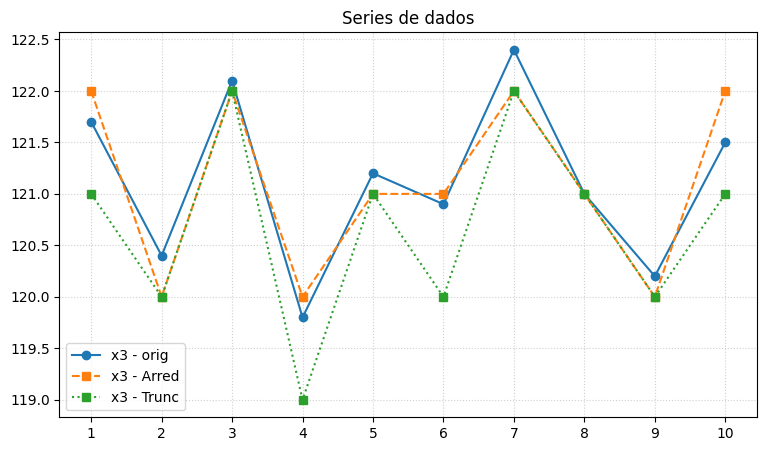

In [35]:
#Graficos

plt.figure(figsize=(9, 5))
x_axis= [1,2,3,4,5,6,7,8,9,10]
#for nome, x in valores_x.items():
#   Ea_trunc = [abs(x - trunc(x, n)) for n in range(5)]
#    Ea_arred = [abs(x - round(x, n)) for n in range(5)]

# Plota a linha de truncamento (contínua) e de arredondamento (tracejada)
plt.plot(x_axis, dados_originais, marker="o", label=f"{nome} - orig")
plt.plot(
        x_axis, dados_arredondandos,marker="s", linestyle="--", label=f"{nome} - Arred"
)
plt.plot(
        x_axis, dados_trunc,marker="s", linestyle=":", label=f"{nome} - Trunc"
)
plt.title("Series de dados")
plt.xticks(x_axis)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()


/tmp/ipykernel_1038/2322974198.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


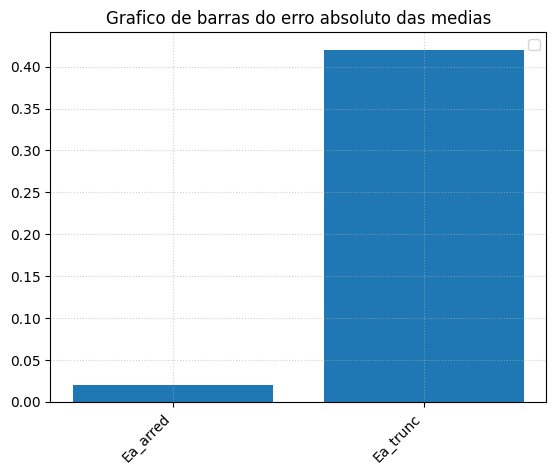

In [36]:
#Codigo de barras dos erros absolutos
x_axis=[1,2]
#Criando uma lista para armazenar os 6 valores de erros em relacao a media
erro_absoluto_das_medias = [Ea_arred_media,Ea_trunc_media]
#Plot do grafico de barras
plt.bar(x_axis,erro_absoluto_das_medias)
plt.title("Grafico de barras do erro absoluto das medias")

#Crinado ista com os nomes das barras
nomes_barras = ['Ea_arred', 'Ea_trunc']
plt.xticks(x_axis, nomes_barras, rotation=45, ha='right')
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()

/tmp/ipykernel_1038/2444019476.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


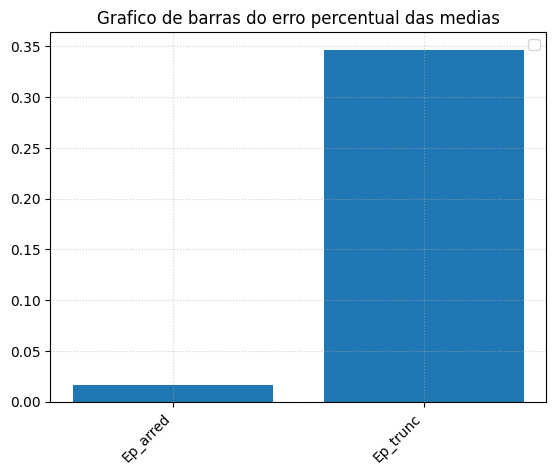

In [37]:
#Codigo de barras dos erros percentuais
x_axis=[1,2]
#Criando uma lista para armazenar os 6 valores de erros em relacao a media
erro_percentuais_das_medias = [Ep_arred_media,Ep_trunc_media]
#Plot do grafico de barras
plt.bar(x_axis,erro_percentuais_das_medias)
plt.title("Grafico de barras do erro percentual das medias")

#Crinado ista com os nomes das barras
nomes_barras = ['Ep_arred', 'Ep_trunc']
plt.xticks(x_axis, nomes_barras, rotation=45, ha='right')
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.show()

/tmp/ipykernel_1038/1915089118.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


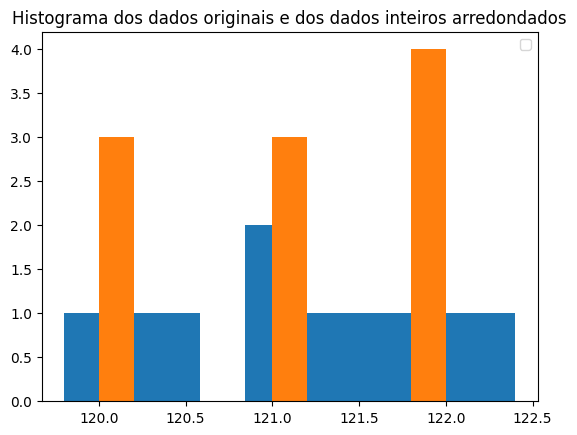

In [38]:
#Histograma dos dados originais e dos dados inteiros arredondados

plt.hist(dados_originais)
plt.hist(dados_arredondandos)

plt.title("Histograma dos dados originais e dos dados inteiros arredondados")
nomes_hist = ['Dados originais', 'Dados arredondados']

plt.legend()
plt.show()


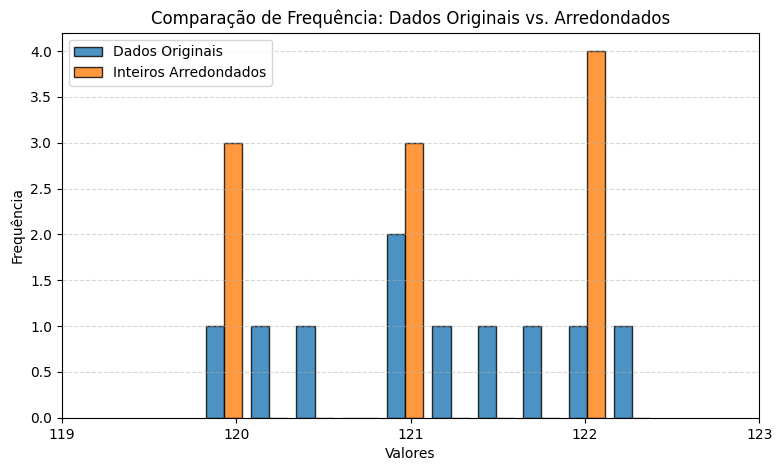

In [39]:
#HISTOGRAMA dos dados originais e dos dados inteiros arredondados.

#definindo os limites exatos das barras para alinhar aos números inteiros
#bins = np.arange(119, 124) - 0.5

#criando o gráfico
plt.figure(figsize=(9, 5))

plt.hist(
    [dados_originais, dados_arredondandos],
    #bins=bins,
    label=["Dados Originais", "Inteiros Arredondados"],
    edgecolor="black",
    alpha=0.8,
)

# Customização do Gráfico
plt.title("Comparação de Frequência: Dados Originais vs. Arredondados")
plt.xlabel("Valores")
plt.ylabel("Frequência")
plt.xticks(range(119, 124))  # Exibe no eixo X apenas os números inteiros
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.show()

A representação inteira claramente se mostrou insuficiente, principalmente em relação a variabilidade da amostra, pois como podemos ver no histograma, os dados arredondados para o inteiro mais proximo apresenta apenas 3 valores diferentes (120,121 e 122), enquanto os dados originais demonstram muito menos homogeneidade.

# 5 - Parte C

In [40]:
# q = [np.pi*r^4*Delta(p)]/8*mu*L
r = 0.80 #mm
L = 0.20 #m
mu = 3.5 / 1000 #Pa
delta_p = 1200 #Pa

q = (np.pi*(r**4)*delta_p)/8*mu*L
print(f"Q com valores fornecidos: {q}")

#calculos de r
r2 = round(r, 1)
r3 = trunc(r, 1)

q1 = (np.pi*(r2**4)*delta_p)/8*mu*L
print(f"Q para r arredondado com 1 casa decimal: {q1}")
erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")


q1 = (np.pi*(r3**4)*delta_p)/8*mu*L
print(f"Q para r truncado com 1 casa decimal: {q1}")
erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

#calculos de mu
mu2 = round(mu, 3)
mu3 = trunc(mu, 3)

q1 = (np.pi*(r**4)*delta_p)/8*mu2*L
print(f"Q para mu arredondado com 3 casas decimais: {q1:.4f}")
erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")


q1 = (np.pi*(r**4)*delta_p)/8*mu3*L
print(f"Q para mu truncado com 3 casas decimais: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

#calculos de Delta_p -> mostrar em kPa
delta_p2 = round(delta_p/1000, 2) #usando kPa como recomendado
delta_p3 = trunc(delta_p/1000, 2) #usando kPa como recomendado

q1 = (np.pi*(r**4)*delta_p2)/8*mu*L
print(f"Q para delta_p arredondado com 2 casas decimais: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

q1 = (np.pi*(r**4)*delta_p3)/8*mu*L
print(f"Q para delta_p truncado com 2 casas decimais: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

q1 = (np.pi*(r2**4)*delta_p2)/8*mu2*L
print(f"Q para todas as medidas arredondas com os respectivos requisitos: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

q1 = (np.pi*(r3**4)*delta_p3)/8*mu3*L
print(f"Q para todas as medidas truncadas com os respectivos requisitos: {q1}")

erro_abs = abs(q-q1)
erro_rel = abs(erro_abs/q)
erro_perc = 100*erro_rel;
print(f"Erro absoluto = {erro_abs}")
print(f"Erro relativo = {erro_rel}")
print(f"Erro percentual = {erro_perc}")

Q com valores fornecidos: 0.13511361684558987
Q para r arredondado com 1 casa decimal: 0.13511361684558987
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0
Q para r truncado com 1 casa decimal: 0.13511361684558987
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0
Q para mu arredondado com 3 casas decimais: 0.1544
Erro absoluto = 0.019301945263655695
Erro relativo = 0.14285714285714285
Erro percentual = 14.285714285714285
Q para mu truncado com 3 casas decimais: 0.11581167158193417
Erro absoluto = 0.019301945263655695
Erro relativo = 0.14285714285714285
Erro percentual = 14.285714285714285
Q para delta_p arredondado com 2 casas decimais: 0.00013511361684558984
Erro absoluto = 0.13497850322874427
Erro relativo = 0.999
Erro percentual = 99.9
Q para delta_p truncado com 2 casas decimais: 0.00013511361684558984
Erro absoluto = 0.13497850322874427
Erro relativo = 0.999
Erro percentual = 99.9
Q para todas as medidas arredondas com os respectivos requisitos: 0.00015441

# 6 Parte - D

In [41]:
#colocando os parametros no SI
r_nominal = 50e-9  #50nm
L = 10e-6  #10 micro m
mu = 3.5e-3  #Pas
delta_p = 5000  #Pa

def calcular_Q(r):
    return (np.pi * (r**4) * delta_p) / (8 * mu * L)


Q_nominal = calcular_Q(r_nominal)

#criando vetor com as variacoes do erro no raio
delta_r_array = np.arange(0.1e-9, 5.1e-9, 0.1e-9)

#Criando listas para os erros máximos para cada delta_r
erro_abs_max = []
erro_rel_max = []
erro_pct_max = []
aprox_linear = []

#Criando listas para os graficos de Q(r-), Q(r) e Q(r+)
Q_menos_list = []
Q_mais_list = []

for dr in delta_r_array:
    r_menos = r_nominal - dr
    r_mais = r_nominal + dr

    Q_menos = calcular_Q(r_menos)
    Q_mais = calcular_Q(r_mais)

    Q_menos_list.append(Q_menos)
    Q_mais_list.append(Q_mais)

    #Calculando o erro maximo (ocorre no ponto mais distante r+)
    e_abs = abs(Q_mais - Q_nominal)
    e_rel = e_abs / Q_nominal
    e_pct = e_rel * 100

    erro_abs_max.append(e_abs)
    erro_rel_max.append(e_rel)
    erro_pct_max.append(e_pct)

    #Aproximação linear da equacao (5)
    aprox_linear.append(4 * (dr / r_nominal))



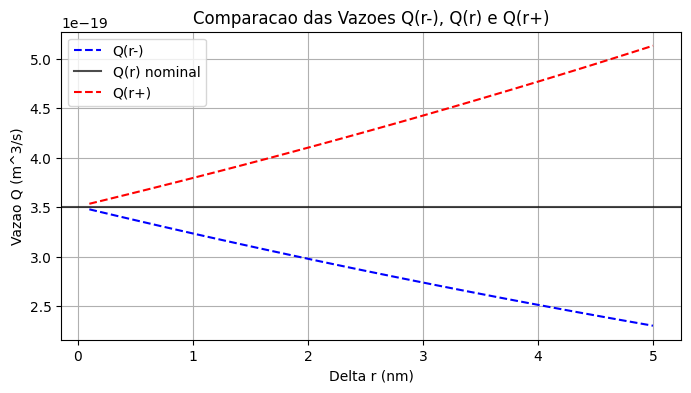

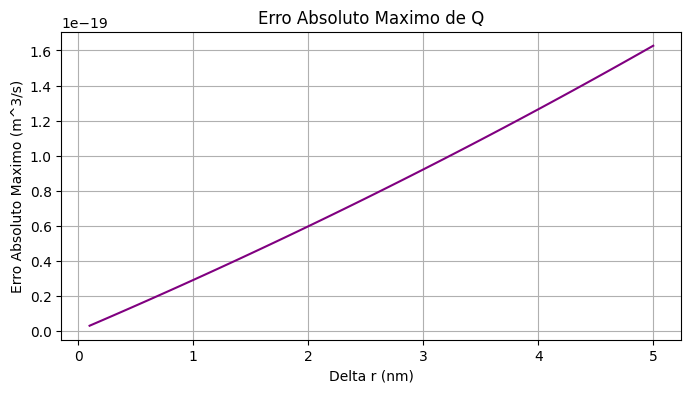

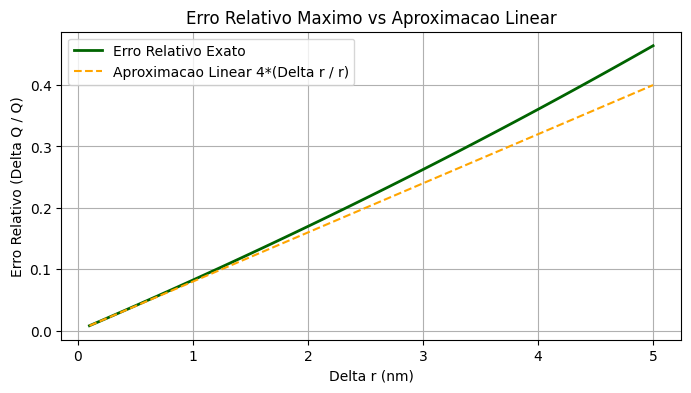

In [43]:
#GRAFICOS
#1 - Grafico de Q(r-), Q(r) e Q(r+)
plt.figure(figsize=(8, 4))
plt.plot(
    delta_r_array * 1e9,
    Q_menos_list,
    label="Q(r-)",
    color="blue",
    linestyle="--",
)
plt.axhline(
    Q_nominal, label="Q(r) nominal", color="black", linestyle="-", alpha=0.7
)
plt.plot(
    delta_r_array * 1e9, Q_mais_list, label="Q(r+)", color="red", linestyle="--"
)
plt.xlabel("Delta r (nm)")
plt.ylabel("Vazao Q (m^3/s)")
plt.title("Comparacao das Vazoes Q(r-), Q(r) e Q(r+)")
plt.legend()
plt.grid(True)
plt.show()

#2 - Erro absoluto maximo
plt.figure(figsize=(8, 4))
plt.plot(delta_r_array * 1e9, erro_abs_max, color="purple")
plt.xlabel("Delta r (nm)")
plt.ylabel("Erro Absoluto Maximo (m^3/s)")
plt.title("Erro Absoluto Maximo de Q")
plt.grid(True)
plt.show()

#3 e 4 - Erro relativo / percentual vs aproximacao linear
plt.figure(figsize=(8, 4))
plt.plot(
    delta_r_array * 1e9,
    erro_rel_max,
    label="Erro Relativo Exato",
    color="darkgreen",
    linewidth=2,
)
plt.plot(
    delta_r_array * 1e9,
    aprox_linear,
    label="Aproximacao Linear 4*(Delta r / r)",
    color="orange",
    linestyle="--",
)
plt.xlabel("Delta r (nm)")
plt.ylabel("Erro Relativo (Delta Q / Q)")
plt.title("Erro Relativo Maximo vs Aproximacao Linear")
plt.legend()
plt.grid(True)
plt.show()